# Param Shah
## 240905320
## CSE-D 33
### Lab 4: Polynomial and Multiple Regression

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import PolynomialFeatures 

Sample Questions:\
Polynomial Regression using Scikit-Learn

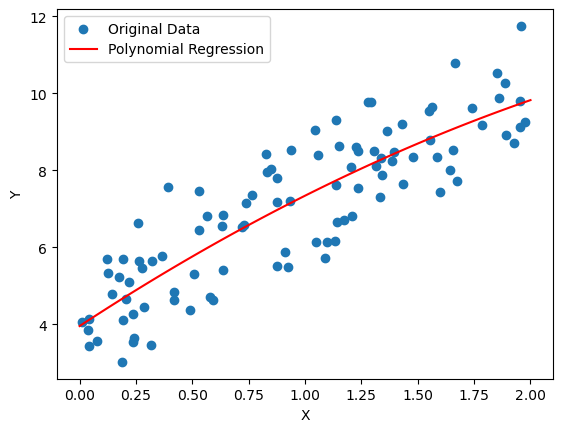

Coefficients:
[[ 0.          3.84100842 -0.45190593]]
Intercept:
[3.95139826]


In [29]:
np.random.seed(0) 
X = 2 * np.random.rand(100, 1) 
Y = 4 + 3 * X + np.random.randn(100, 1) 
degree = 2 
poly_features = PolynomialFeatures(degree=degree) 
X_poly = poly_features.fit_transform(X) 
model = LinearRegression() 
model.fit(X_poly, Y) 
X_new = np.linspace(0, 2, 100).reshape(-1, 1) 
X_new_poly = poly_features.transform(X_new) 
Y_new = model.predict(X_new_poly) 
plt.scatter(X, Y, label='Original Data') 
plt.plot(X_new, Y_new, 'r-', label='Polynomial Regression') 
plt.xlabel('X') 
plt.ylabel('Y') 
plt.legend() 
plt.show() 
coefficients = model.coef_ 
intercept = model.intercept_ 
print("Coefficients:") 
print(coefficients) 
print("Intercept:") 
print(intercept)

Q1) The data set of size n = 15 (Yield data) contains measurements of yield from an experiment done at five different temperature levels. The variables are y = yield and x = temperature in degrees Fahrenheit. \
a. Create a CSV file with sample data. \
b. Write a Python function program to: \
Find the fitted simple linear and polynomial regression equations for the given data. \
c. Compare the coefficients obtained from manually intuitive and matrix  formulation methods with 
your program. \
d. Plot the scatterplot of the raw data and then another scatterplot with lines pertaining to a linear fit and a quadratic fit overlayed. \
e. Compute the error, MSE, and RMSE. 

--- Coefficient Comparison ---
Matrix Formulation:
  Intercept (a): 2.306306
  Slope (b):     0.006757

Manually Intuitive Method:
  Intercept (a): 2.306306
  Slope (b):     0.006757

Do the coefficients match? Yes
--- Regression Coefficients ---
Linear Regression Coefficients (Intercept, Slope): [2.30630631 0.00675676]
Polynomial Regression (Degree 2) Coefficients (a0, a1, a2): [ 7.96048110e+00 -1.53711340e-01  1.07560137e-03]

--- Error Metrics ---
Linear Fit:
  MSE:  0.1327
  RMSE: 0.3643

Quadratic Polynomial Fit:
  MSE:  0.0478
  RMSE: 0.2186



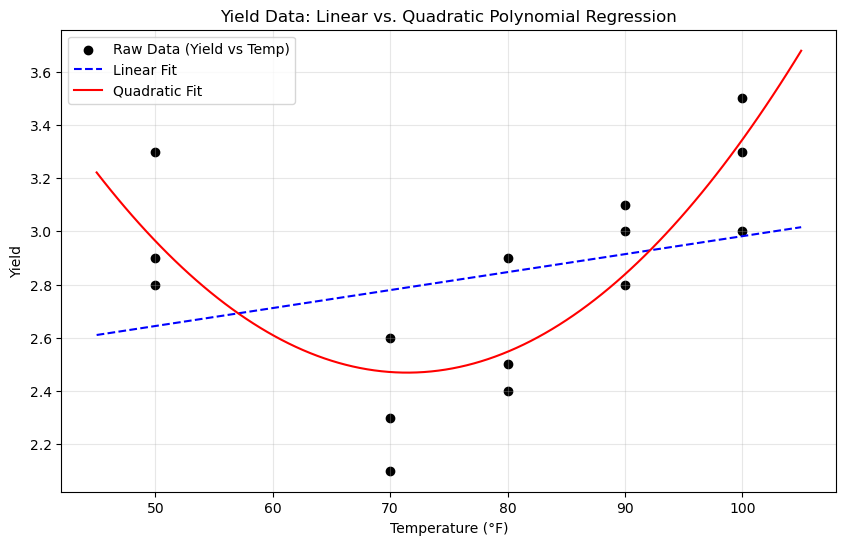

In [30]:
csv_file_path = 'Yield.csv'

data = pd.read_csv(csv_file_path)
x = data['Temp (X)'].values
y = data['Yield (Y)'].values
n = len(x)

X_linear = np.column_stack((np.ones(n), x))
coeff_linear = np.linalg.inv(X_linear.T.dot(X_linear)).dot(X_linear.T).dot(y)
b0_matrix, b1_matrix = coeff_linear

sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x_squared = np.sum(x**2)
b1_intuitive = (n * sum_xy - sum_x * sum_y) / (n * sum_x_squared - sum_x**2)
b0_intuitive = np.mean(y) - b1_intuitive * np.mean(x)

print("--- Coefficient Comparison ---")
print("Matrix Formulation:")
print(f"  Intercept (a): {b0_matrix:.6f}")
print(f"  Slope (b):     {b1_matrix:.6f}\n")

print("Manually Intuitive Method:")
print(f"  Intercept (a): {b0_intuitive:.6f}")
print(f"  Slope (b):     {b1_intuitive:.6f}\n")

match_a = np.isclose(b0_matrix, b0_intuitive)
match_b = np.isclose(b1_matrix, b1_intuitive)
print(f"Do the coefficients match? {'Yes' if match_a and match_b else 'No'}")

X_poly = np.column_stack((np.ones(n), x, x**2))

coeff_poly = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)

print("--- Regression Coefficients ---")
print(f"Linear Regression Coefficients (Intercept, Slope): {coeff_linear}")
print(f"Polynomial Regression (Degree 2) Coefficients (a0, a1, a2): {coeff_poly}\n")

y_pred_linear = X_linear.dot(coeff_linear)
y_pred_poly = X_poly.dot(coeff_poly)

error_linear = y - y_pred_linear
mse_linear = np.sum(error_linear**2) / n
rmse_linear = np.sqrt(mse_linear)

error_poly = y - y_pred_poly
mse_poly = np.sum(error_poly**2) / n
rmse_poly = np.sqrt(mse_poly)

print("--- Error Metrics ---")
print("Linear Fit:")
print(f"  MSE:  {mse_linear:.4f}")
print(f"  RMSE: {rmse_linear:.4f}")
print("\nQuadratic Polynomial Fit:")
print(f"  MSE:  {mse_poly:.4f}")
print(f"  RMSE: {rmse_poly:.4f}\n")

x_plot = np.linspace(min(x) - 5, max(x) + 5, 100)

y_plot_linear = coeff_linear[0] + coeff_linear[1] * x_plot
y_plot_poly = coeff_poly[0] + coeff_poly[1] * x_plot + coeff_poly[2] * (x_plot**2)

plt.figure(figsize=(10, 6))

plt.scatter(x, y, color='black', label='Raw Data (Yield vs Temp)')
plt.plot(x_plot, y_plot_linear, color='blue', linestyle='--', label='Linear Fit')
plt.plot(x_plot, y_plot_poly, color='red', label='Quadratic Fit')

plt.title('Yield Data: Linear vs. Quadratic Polynomial Regression')
plt.xlabel('Temperature (°F)')
plt.ylabel('Yield')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Q2) When heart muscle is deprived of oxygen, the tissue dies and leads to a heart attack ("myocardial infarction"). Apparently, cooling the heart reduces the size of the heart attack. It is not known, however, whether cooling is only effective if it takes place before the blood, flow to the heart becomes restricted. \
Some researchers (Hale, et al, 1997) hypothesized that cooling the heart would be effective in reducing the size of the heart attack even if it takes place after the blood flow becomes restricted.\
To  investigate  their  hypothesis,  the  researchers  conducted  an experiment  on  32 anesthetized  rabbits that were subjected to a heart attack. The researchers established three experimental groups: \
▪ Rabbits whose hearts were cooled to 6º C within 5 minutes of the blocked artery ("early cooling") \
▪ Rabbits whose hearts were cooled to 6º C within 25 minutes of the blocked artery ("late cooling") \
▪ Rabbits whose hearts were not cooled at all ("no cooling") \
At the end of the experiment, the researchers measured the size of the infarcted (i.e., damaged) area (in grams) in each of the 32 rabbits. But, as you can imagine, there is great variability in the size of hearts. \
The size of a rabbit's infarcted area may be large only because it has a larger heart. Therefore, in order to adjust for differences in heart sizes, the researchers also measured the size of the region at risk for 
infarction (in grams) in each of the 32 rabbits. 

With their measurements in hand, the researchers' primary research question was: Does the mean size 
of  the  infarcted  area  differ  among  the  three treatment  groups  —  no  cooling,  early  cooling,  and  late cooling — when controlling for the size of the region at risk for infarction? \
A regression model that the researchers might use in answering their research question is: \
yi=(β0+β1xi1+β2xi2+β3xi3)+εi \
where: 
▪ yi is the size of the infarcted area (in grams) of rabbit i \
▪ xi1 is the size of the region at risk (in grams) of rabbit i \
▪ xi2 = 1 if early cooling of rabbit i, 0 if not \
▪ xi3 = 1 if late cooling of rabbit i, 0 if not \
and the independent error terms εi follow a normal distribution with mean 0 and equal variance σ2. \
Illustrates the need for being able to "translate" a research question into a statistical procedure. Often, the procedure involves four steps, namely: \
• formulating a multiple regression model \
• determining how the model helps answer the research question \
• checking the model \
• and performing a hypothesis test (or calculating a confidence interval)

a. Create a CSV file with sample data. \
b. Write a Python function program to: \
c. Find the fitted multiple linear regression equation for the given data. \
d. Compare the coefficients obtained manually using intuitive and matrix formulation methods with your program. \
e. Plot the data adorned with the estimated regression equation. \
f. Compute the error, MSE, and RMSE.

--- Coefficient Comparison ---
1. Matrix Formulation:
  Intercept (b0): -0.134536
  Region Risk Slope (b1):  0.612655
  Early Cooling Dummy (b2):  -0.243482
  Late Cooling Dummy (b3):  -0.065656

2. Manually Intuitive Method:
  Intercept (b0): -0.134536
  Region Risk Slope (b1):  0.612655
  Early Cooling Dummy (b2):  -0.243482
  Late Cooling Dummy (b3):  -0.065656

Do the coefficients match perfectly? Yes
Equation: Y = -0.1345 + 0.6127*X1 + -0.2435*X2 + -0.0657*X3

--- Error Metrics ---
MSE:  0.017028
RMSE: 0.130493


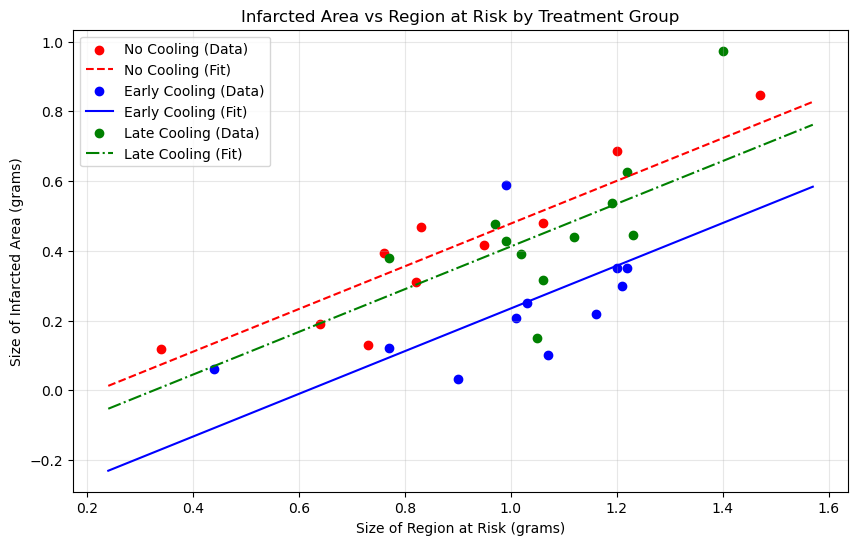

In [31]:
data = pd.read_csv('Infarc_Rate.csv')

Y = data['Infarc'].values
X1 = data['Area'].values
X2 = data['X2'].values
X3 = data['X3'].values
n = len(Y)


X_matrix = np.column_stack((np.ones(n), X1, X2, X3))
beta = np.linalg.inv(X_matrix.T.dot(X_matrix)).dot(X_matrix.T).dot(Y)
b0, b1, b2, b3 = beta

sum_Y = np.sum(Y)
sum_X1 = np.sum(X1)
sum_X2 = np.sum(X2)
sum_X3 = np.sum(X3)

sum_X1_sq = np.sum(X1**2)
sum_X2_sq = np.sum(X2**2)
sum_X3_sq = np.sum(X3**2)

sum_X1Y = np.sum(X1 * Y)
sum_X2Y = np.sum(X2 * Y)
sum_X3Y = np.sum(X3 * Y)

sum_X1X2 = np.sum(X1 * X2)
sum_X1X3 = np.sum(X1 * X3)
sum_X2X3 = np.sum(X2 * X3)

A_manual = np.array([
    [n, sum_X1, sum_X2, sum_X3],
    [sum_X1, sum_X1_sq, sum_X1X2, sum_X1X3],
    [sum_X2, sum_X1X2, sum_X2_sq, sum_X2X3],
    [sum_X3, sum_X1X3, sum_X2X3, sum_X3_sq]
])

B_manual = np.array([sum_Y, sum_X1Y, sum_X2Y, sum_X3Y])

beta_manual = np.linalg.solve(A_manual, B_manual)

print("--- Coefficient Comparison ---")
print("1. Matrix Formulation:")
print(f"  Intercept (b0): {beta[0]:.6f}")
print(f"  Region Risk Slope (b1):  {beta[1]:.6f}")
print(f"  Early Cooling Dummy (b2):  {beta[2]:.6f}")
print(f"  Late Cooling Dummy (b3):  {beta[3]:.6f}\n")

print("2. Manually Intuitive Method:")
print(f"  Intercept (b0): {beta_manual[0]:.6f}")
print(f"  Region Risk Slope (b1):  {beta_manual[1]:.6f}")
print(f"  Early Cooling Dummy (b2):  {beta_manual[2]:.6f}")
print(f"  Late Cooling Dummy (b3):  {beta_manual[3]:.6f}\n")
match = np.allclose(beta, beta_manual)
print(f"Do the coefficients match perfectly? {'Yes' if match else 'No'}")

print(f"Equation: Y = {b0:.4f} + {b1:.4f}*X1 + {b2:.4f}*X2 + {b3:.4f}*X3\n")
Y_pred = X_matrix.dot(beta)

errors = Y - Y_pred

mse = np.sum(errors**2) / n

rmse = np.sqrt(mse)

print("--- Error Metrics ---")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")


plt.figure(figsize=(10, 6))

x_plot = np.linspace(min(X1) - 0.1, max(X1) + 0.1, 100)

y_plot_no_cool = b0 + b1 * x_plot
mask_no_cool = (X2 == 0) & (X3 == 0)
plt.scatter(X1[mask_no_cool], Y[mask_no_cool], color='red', label='No Cooling (Data)')
plt.plot(x_plot, y_plot_no_cool, color='red', linestyle='--', label='No Cooling (Fit)')

y_plot_early = (b0 + b2) + b1 * x_plot
mask_early = (X2 == 1) & (X3 == 0)
plt.scatter(X1[mask_early], Y[mask_early], color='blue', label='Early Cooling (Data)')
plt.plot(x_plot, y_plot_early, color='blue', linestyle='-', label='Early Cooling (Fit)')

y_plot_late = (b0 + b3) + b1 * x_plot
mask_late = (X2 == 0) & (X3 == 1)
plt.scatter(X1[mask_late], Y[mask_late], color='green', label='Late Cooling (Data)')
plt.plot(x_plot, y_plot_late, color='green', linestyle='-.', label='Late Cooling (Fit)')

plt.title('Infarcted Area vs Region at Risk by Treatment Group')
plt.xlabel('Size of Region at Risk (grams)')
plt.ylabel('Size of Infarcted Area (grams)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()